In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gc
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.model_selection import train_test_split

In [3]:
# Open the file
file_path = "Halfmile3D_add_geom_sorted.hdf5"

with h5py.File(file_path, "r") as f:
    # Go to the data group
    group = f["TRACE_DATA"]["DEFAULT"]

    # Print all the keys (datasets) available
    print("=" * 60)
    print("DATASETS IN THIS FILE:")
    print("=" * 60)
    for key in group.keys():
        print(f"  - {key}")

DATASETS IN THIS FILE:
  - ALIAS_FREQ
  - ALIAS_SLOPE
  - AZIMUTH
  - CDP
  - CDPTRACE
  - CDP_X
  - CDP_Y
  - CHANNEL
  - COORD_SCALE
  - COORD_UNIT
  - CORR
  - CROSSLINE
  - DATA_START
  - DATA_STOP
  - DAY
  - DELAY
  - FIRST_BREAK_TIME
  - FTRACE
  - GAIN_TYPE
  - GAP_SIZE
  - HIGH_CUT_FREQ
  - HIGH_CUT_SLOPE
  - HORI_SUM
  - HOUR
  - HT_SCALE
  - INLINE
  - INSTR_GAIN_CONSTANT
  - INSTR_INIT_GAIN
  - INTERNAL_SORT1
  - INTERNAL_SORT2
  - LAG_TIME_A
  - LAG_TIME_B
  - LASTTR
  - LINE
  - LOW_CUT_FREQ
  - LOW_CUT_SLOPE
  - MINUTE
  - MODELLED_BREAK_TIME
  - NOTCH_FREQ
  - NOTCH_SLOPE
  - OFFSET
  - OFFSET_FLT
  - OVERTRAVEL
  - RECORDNUM
  - REC_DAT
  - REC_HT
  - REC_NUM_FIRST_FIELD
  - REC_NUM_LAST_FIELD
  - REC_NUM_POS1
  - REC_PEG
  - REC_PEG_DIST
  - REC_STATIC
  - REC_UPHOLE_TIME
  - REC_WATER
  - REC_X
  - REC_Y
  - REEL
  - REF_MODEL_REC_STATIC
  - REF_MODEL_SRC_STATIC
  - REF_RESID_REC_STATIC
  - REF_RESID_SRC_STATIC
  - REF_TOTAL_STATIC
  - REPEAT
  - SAMP_NUM
  - SAMP_RA

In [4]:
import h5py

with h5py.File("Halfmile3D_add_geom_sorted.hdf5", "r") as f:
    group = f["TRACE_DATA"]["DEFAULT"]

    # List the datasets we care about and their shapes
    important_datasets = [
        "data_array",
        "SHOTID",
        "CHANNEL",
        "SPARE1",
        "OFFSET",
        "REC_X",
        "REC_Y",
    ]

    print("=" * 60)
    print("DATASET SHAPES:")
    print("=" * 60)
    for key in important_datasets:
        data = group[key]
        print(f"{key:15s} -> Shape: {data.shape}, Dtype: {data.dtype}")

    print("\n" + "=" * 60)
    print("FIRST 10 VALUES OF EACH IMPORTANT DATASET:")
    print("=" * 60)

    # Show first 10 values of each important dataset
    for key in important_datasets:
        data = group[key][()]  # Load the data
        if data.ndim == 2:
            values = data[:10, 0]  # First 10 rows, first column
        else:
            values = data[:10]  # First 10 values

        print(f"\n{key}:")
        print(f"  First 10 values: {values}")

        # If it's SPARE1, also show it in milliseconds (samples * 2ms)
        if key == "SPARE1":
            print(f"  First 10 values in ms: {values * 2}")

DATASET SHAPES:
data_array      -> Shape: (1099559, 751), Dtype: float32
SHOTID          -> Shape: (1099559, 1), Dtype: uint32
CHANNEL         -> Shape: (1099559, 1), Dtype: uint32
SPARE1          -> Shape: (1099559, 1), Dtype: int32
OFFSET          -> Shape: (1099559, 1), Dtype: int32
REC_X           -> Shape: (1099559, 1), Dtype: int32
REC_Y           -> Shape: (1099559, 1), Dtype: int32

FIRST 10 VALUES OF EACH IMPORTANT DATASET:

data_array:
  First 10 values: [-0.00280977 -0.01594777 -0.0028436  -0.00595661  0.00075043 -0.00135821
 -0.00022832 -0.00111393  0.00517564  0.00236528]

SHOTID:
  First 10 values: [20021449 20021449 20021449 20021449 20021449 20021449 20021449 20021449
 20021449 20021449]

CHANNEL:
  First 10 values: [ 1  2  3  4  5  6  7  8  9 10]

SPARE1:
  First 10 values: [122 127 132 137 141 146 148 151 153 156]
  First 10 values in ms: [244 254 264 274 282 292 296 302 306 312]

OFFSET:
  First 10 values: [540 559 578 598 617 636 656 675 695 715]

REC_X:
  First 10 

In [5]:
import h5py

with h5py.File("Halfmile3D_add_geom_sorted.hdf5", "r") as f:
    group = f["TRACE_DATA"]["DEFAULT"]

    shotids = group["SHOTID"][()].flatten()
    unique_shots = np.unique(shotids)

    print("=" * 60)
    print("TRACES PER SHOT (First 10 shots):")
    print("=" * 60)

    for i, shot_id in enumerate(unique_shots[:10]):
        mask = shotids == shot_id
        n_traces = np.sum(mask)
        print(f"Shot {shot_id}: {n_traces} traces")

    print("\n" + "=" * 60)
    print("STATISTICS:")
    print("=" * 60)

    # Count traces per shot for ALL shots
    traces_per_shot = []
    for shot_id in unique_shots:
        mask = shotids == shot_id
        traces_per_shot.append(np.sum(mask))

    traces_per_shot = np.array(traces_per_shot)

    print(f"Total shots: {len(unique_shots)}")
    print(f"Total traces: {np.sum(traces_per_shot)}")
    print(f"Average traces per shot: {np.mean(traces_per_shot):.1f}")
    print(f"Min traces per shot: {traces_per_shot.min()}")
    print(f"Max traces per shot: {traces_per_shot.max()}")
    print(f"Standard deviation: {np.std(traces_per_shot):.1f}")

    # Check if any shot has exactly 1594 traces
    count_1594 = np.sum(traces_per_shot == 1594)
    print(f"\nShots with exactly 1594 traces: {count_1594} out of {len(unique_shots)}")

TRACES PER SHOT (First 10 shots):
Shot 20021449: 1578 traces
Shot 20021451: 1578 traces
Shot 20021453: 1578 traces
Shot 20021455: 1578 traces
Shot 20021457: 1575 traces
Shot 20021459: 1578 traces
Shot 20021461: 1578 traces
Shot 20021462: 1578 traces
Shot 20021463: 1578 traces
Shot 20021464: 1578 traces

STATISTICS:
Total shots: 690
Total traces: 1099559
Average traces per shot: 1593.6
Min traces per shot: 1575
Max traces per shot: 1604
Standard deviation: 12.4

Shots with exactly 1594 traces: 0 out of 690


First Shot ID: 20021449
Number of traces in this shot: 1578
Number of samples per trace: 751


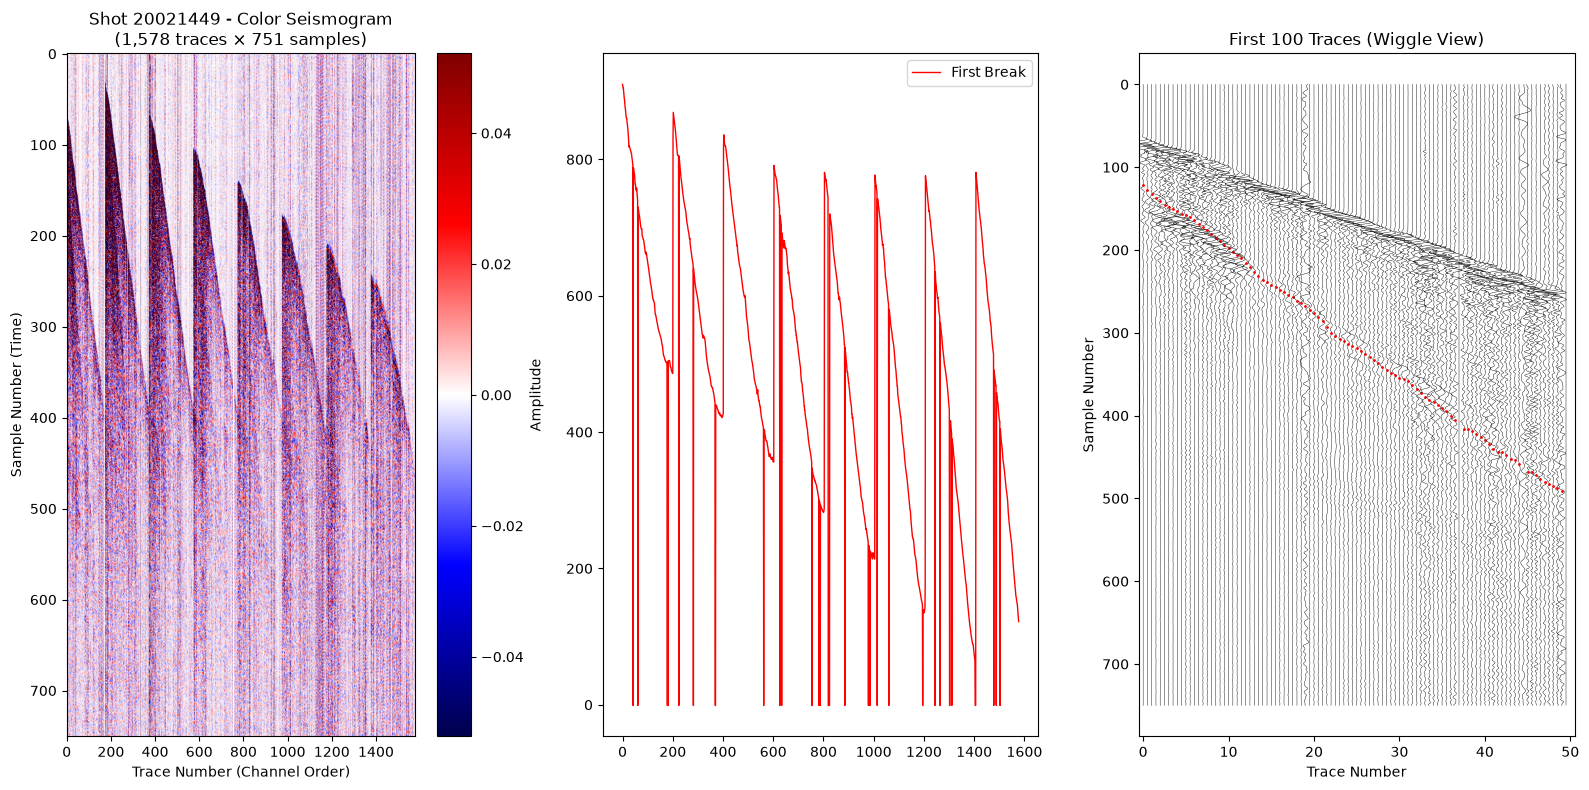

In [6]:
import h5py
import numpy as np

# Open the file
with h5py.File("Halfmile3D_add_geom_sorted.hdf5", "r") as f:
    group = f["TRACE_DATA"]["DEFAULT"]

    # Load SHOTID for all traces
    shotids = group["SHOTID"][()].flatten()

    # Find the first shot
    unique_shots = np.unique(shotids)
    first_shot_id = unique_shots[0]
    print(f"First Shot ID: {first_shot_id}")

    # Get all traces for this shot
    mask = shotids == first_shot_id
    shot_data = group["data_array"][()][mask]  # (n_traces, 751)
    shot_picks = group["SPARE1"][()][mask].flatten()  # (n_traces,)

    print(f"Number of traces in this shot: {shot_data.shape[0]}")
    print(f"Number of samples per trace: {shot_data.shape[1]}")

    # Plot the seismogram as a 2D image
    fig, axes = plt.subplots(1, 3, figsize=(16, 8))

    # --- Left plot: Color seismogram ---
    ax1 = axes[0]
    # Transpose so time goes down the Y axis
    im = ax1.imshow(
        shot_data.T,
        cmap="seismic",
        aspect="auto",
        vmin=-np.percentile(np.abs(shot_data), 95),
        vmax=np.percentile(np.abs(shot_data), 95),
    )
    ax1.set_xlabel("Trace Number (Channel Order)")
    ax1.set_ylabel("Sample Number (Time)")
    ax1.set_title(
        f"Shot {first_shot_id} - Color Seismogram\n(1,578 traces × 751 samples)"
    )
    plt.colorbar(im, ax=ax1, label="Amplitude")

    # Overlay the first break picks as a red line
    ax2 = axes[1]
    ax2.plot(
        range(len(shot_picks)), shot_picks[::-1], "r-", linewidth=1, label="First Break"
    )
    ax2.legend()

    # --- Right plot: Wiggle seismogram (first 100 traces) ---
    ax2 = axes[2]
    n_traces_to_show = min(100, shot_data.shape[0])
    for i in range(n_traces_to_show):
        trace = shot_data[i, :]
        # Normalize each trace
        trace = trace / (np.max(np.abs(trace)) + 1e-10)
        # Plot with offset
        ax2.plot(trace + i * 0.5, range(len(trace)), "k-", linewidth=0.3)
        # Mark the first break
        pick = int(shot_picks[i])
        if pick > 0 and pick < len(trace):
            ax2.plot(i * 0.5, pick, "ro", markersize=1)

    ax2.set_xlabel("Trace Number")
    ax2.set_ylabel("Sample Number")
    ax2.set_title(f"First {n_traces_to_show} Traces (Wiggle View)")
    ax2.invert_yaxis()  # Seismic data has time going down
    ax2.set_xlim(-0.5, n_traces_to_show * 0.5 + 0.5)

    plt.tight_layout()
    plt.show()

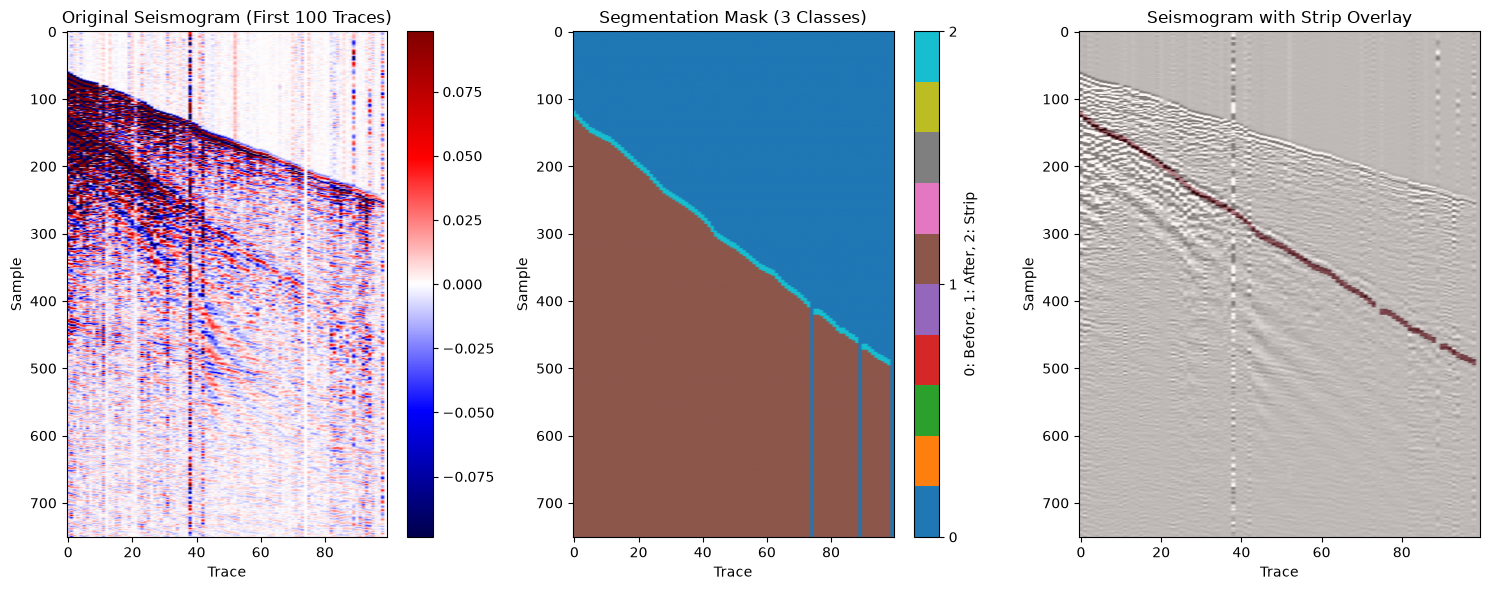

Mask shape: (1578, 751)
Unique values in mask: [0 1 2]
Class distribution:
  Class 0 (Before): 805022 pixels
  Class 1 (After):  367809 pixels
  Class 2 (Strip):  12247 pixels


In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np


def create_segmentation_mask(picks, n_samples=751, strip_width=8):
    """
    Create a 3-class segmentation mask.
    Class 0: Before first break
    Class 2: Strip around first break (strip_width samples)
    Class 1: After first break
    """
    n_traces = len(picks)
    mask = np.zeros((n_traces, n_samples), dtype=np.int64)

    for i, pick in enumerate(picks):
        if pick <= 0 or pick >= n_samples:
            # Unlabeled - keep as class 0
            continue

        pick_int = int(np.round(pick))
        half_width = strip_width // 2

        # Class 2: strip around pick
        start_strip = max(0, pick_int - half_width)
        end_strip = min(n_samples, pick_int + half_width + 1)
        mask[i, start_strip:end_strip] = 2

        # Class 1: after strip
        mask[i, end_strip:] = 1

        # Class 0: before strip (already zeros)

    return mask


# Load the first shot
with h5py.File("Halfmile3D_add_geom_sorted.hdf5", "r") as f:
    group = f["TRACE_DATA"]["DEFAULT"]

    shotids = group["SHOTID"][()].flatten()
    unique_shots = np.unique(shotids)
    first_shot_id = unique_shots[0]

    mask = shotids == first_shot_id
    shot_data = group["data_array"][()][mask]
    shot_picks = group["SPARE1"][()][mask].flatten()

# Create the segmentation mask
seg_mask = create_segmentation_mask(shot_picks, n_samples=751, strip_width=8)

# Visualize the mask
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# 1. Original seismogram (first 100 traces)
ax1 = axes[0]
data_subset = shot_data[:100, :]
im1 = ax1.imshow(
    data_subset.T,
    cmap="seismic",
    aspect="auto",
    vmin=-np.percentile(np.abs(data_subset), 95),
    vmax=np.percentile(np.abs(data_subset), 95),
)
ax1.set_title("Original Seismogram (First 100 Traces)")
ax1.set_xlabel("Trace")
ax1.set_ylabel("Sample")
plt.colorbar(im1, ax=ax1)

# 2. Segmentation mask (first 100 traces)
ax2 = axes[1]
mask_subset = seg_mask[:100, :]
im2 = ax2.imshow(mask_subset.T, cmap="tab10", aspect="auto", vmin=0, vmax=2)
ax2.set_title("Segmentation Mask (3 Classes)")
ax2.set_xlabel("Trace")
ax2.set_ylabel("Sample")
plt.colorbar(im2, ax=ax2, ticks=[0, 1, 2], label="0: Before, 1: After, 2: Strip")

# 3. Overlay: Mask on Seismogram
ax3 = axes[2]
# Show seismogram in grayscale
im3 = ax3.imshow(
    data_subset.T,
    cmap="gray",
    aspect="auto",
    vmin=-np.percentile(np.abs(data_subset), 95),
    vmax=np.percentile(np.abs(data_subset), 95),
)
# Overlay the strip (Class 2) in red
strip_mask = (mask_subset == 2).T
ax3.imshow(strip_mask, cmap="Reds", aspect="auto", alpha=0.5)
ax3.set_title("Seismogram with Strip Overlay")
ax3.set_xlabel("Trace")
ax3.set_ylabel("Sample")

plt.tight_layout()
plt.savefig("nono")
plt.show()

print(f"Mask shape: {seg_mask.shape}")
print(f"Unique values in mask: {np.unique(seg_mask)}")
print("Class distribution:")
print(f"  Class 0 (Before): {np.sum(seg_mask == 0)} pixels")
print(f"  Class 1 (After):  {np.sum(seg_mask == 1)} pixels")
print(f"  Class 2 (Strip):  {np.sum(seg_mask == 2)} pixels")

Total shots available: 690
Visualizing first 10 shots...
Shot 20021449: 1578 traces, 1539 valid picks, pick range: 65-910 samples
Shot 20021451: 1578 traces, 1532 valid picks, pick range: 64-909 samples
Shot 20021453: 1578 traces, 1528 valid picks, pick range: 51-899 samples
Shot 20021455: 1578 traces, 1542 valid picks, pick range: 42-899 samples
Shot 20021457: 1575 traces, 1545 valid picks, pick range: 35-894 samples
Shot 20021459: 1578 traces, 1540 valid picks, pick range: 39-901 samples
Shot 20021461: 1578 traces, 1537 valid picks, pick range: 44-884 samples
Shot 20021462: 1578 traces, 1543 valid picks, pick range: 56-882 samples
Shot 20021463: 1578 traces, 1549 valid picks, pick range: 61-874 samples
Shot 20021464: 1578 traces, 1535 valid picks, pick range: 52-872 samples


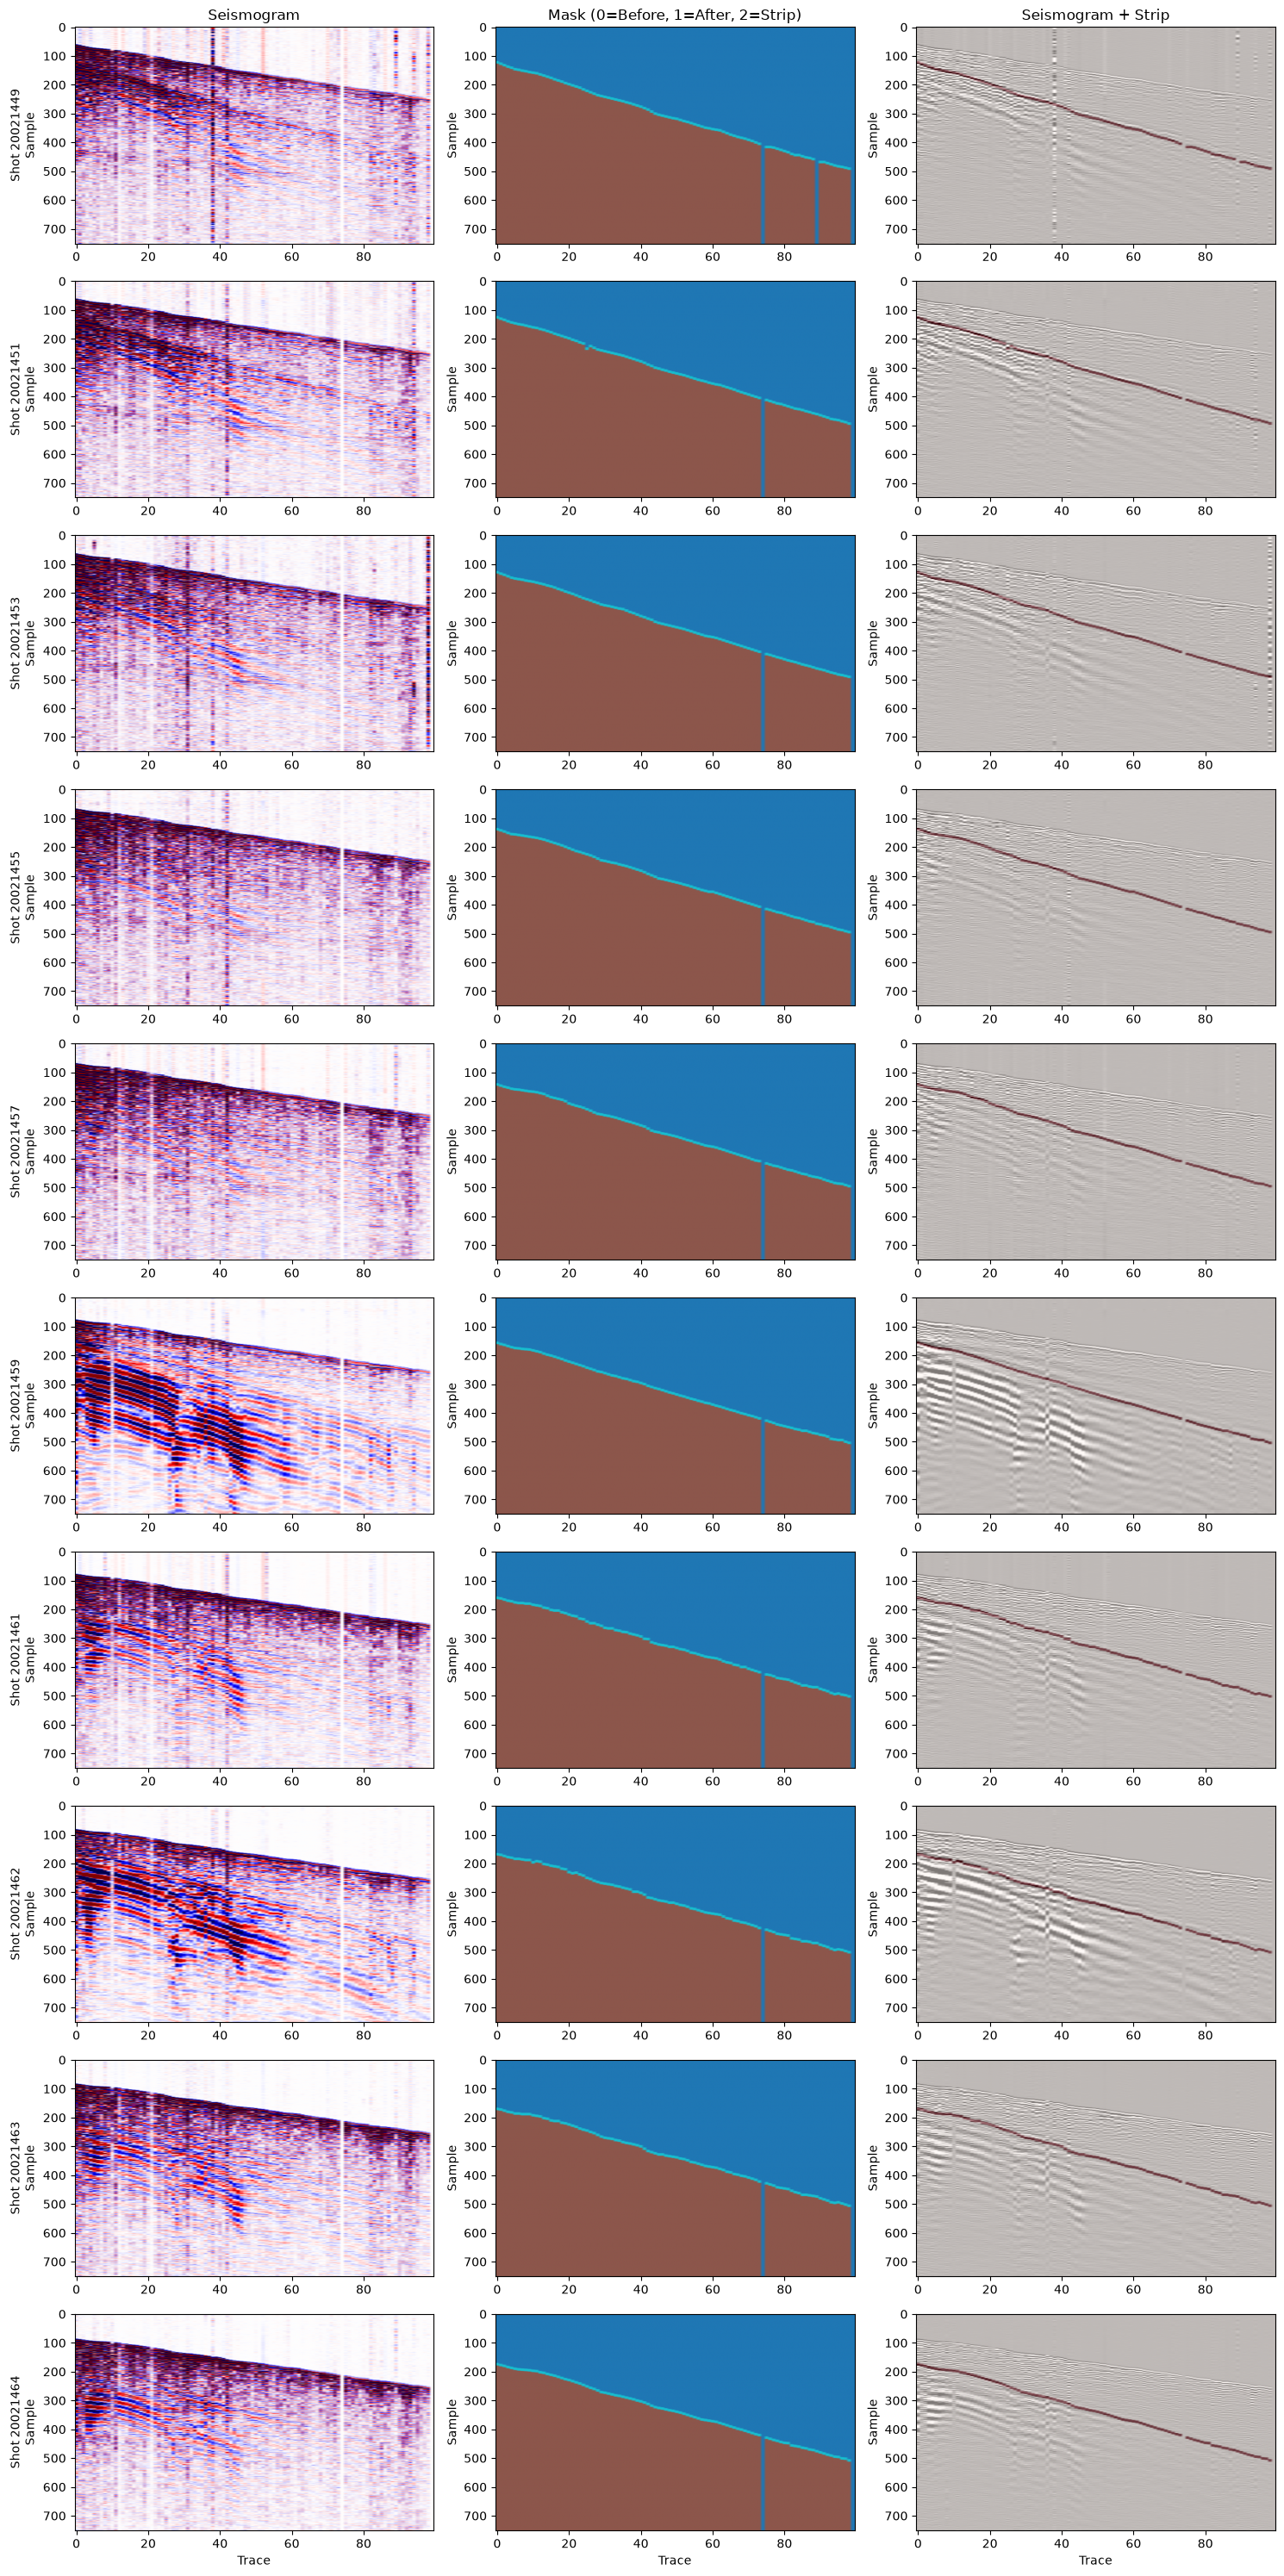

In [8]:
import h5py
import matplotlib.pyplot as plt
import numpy as np


def create_segmentation_mask(picks, n_samples=751, strip_width=8):
    """Create 3-class segmentation mask."""
    n_traces = len(picks)
    mask = np.zeros((n_traces, n_samples), dtype=np.int64)

    for i, pick in enumerate(picks):
        if pick <= 0 or pick >= n_samples:
            continue

        pick_int = int(np.round(pick))
        half_width = strip_width // 2

        start_strip = max(0, pick_int - half_width)
        end_strip = min(n_samples, pick_int + half_width + 1)
        mask[i, start_strip:end_strip] = 2
        mask[i, end_strip:] = 1

    return mask


# Open the file
with h5py.File("Halfmile3D_add_geom_sorted.hdf5", "r") as f:
    group = f["TRACE_DATA"]["DEFAULT"]

    # Get all unique shots
    shotids = group["SHOTID"][()].flatten()
    unique_shots = np.unique(shotids)

    print(f"Total shots available: {len(unique_shots)}")
    print("Visualizing first 10 shots...")
    print("=" * 60)

    # Take first 10 shots
    n_shots_to_show = 10
    selected_shots = unique_shots[:n_shots_to_show]

    # Create a figure with 10 rows and 3 columns
    fig, axes = plt.subplots(n_shots_to_show, 3, figsize=(15, n_shots_to_show * 3))

    for row, shot_id in enumerate(selected_shots):
        # Get traces for this shot
        mask = shotids == shot_id
        shot_data = group["data_array"][()][mask]
        shot_picks = group["SPARE1"][()][mask].flatten()

        # Take first 100 traces for visualization (to keep plots clean)
        n_traces = min(100, shot_data.shape[0])
        data_subset = shot_data[:n_traces, :]
        picks_subset = shot_picks[:n_traces]

        # Create segmentation mask
        seg_mask = create_segmentation_mask(picks_subset, n_samples=751, strip_width=8)

        # --- Plot 1: Seismogram ---
        ax1 = axes[row, 0]
        im1 = ax1.imshow(
            data_subset.T,
            cmap="seismic",
            aspect="auto",
            vmin=-np.percentile(np.abs(data_subset), 95),
            vmax=np.percentile(np.abs(data_subset), 95),
        )
        ax1.set_ylabel(f"Shot {shot_id}\nSample")
        if row == 0:
            ax1.set_title("Seismogram")
        if row == n_shots_to_show - 1:
            ax1.set_xlabel("Trace")

        # --- Plot 2: Segmentation Mask ---
        ax2 = axes[row, 1]
        im2 = ax2.imshow(seg_mask.T, cmap="tab10", aspect="auto", vmin=0, vmax=2)
        ax2.set_ylabel("Sample")
        if row == 0:
            ax2.set_title("Mask (0=Before, 1=After, 2=Strip)")
        if row == n_shots_to_show - 1:
            ax2.set_xlabel("Trace")

        # --- Plot 3: Overlay ---
        ax3 = axes[row, 2]
        # Gray background
        ax3.imshow(
            data_subset.T,
            cmap="gray",
            aspect="auto",
            vmin=-np.percentile(np.abs(data_subset), 95),
            vmax=np.percentile(np.abs(data_subset), 95),
        )
        # Overlay strip in red
        strip_mask = (seg_mask == 2).T
        ax3.imshow(strip_mask, cmap="Reds", aspect="auto", alpha=0.5)
        ax3.set_ylabel("Sample")
        if row == 0:
            ax3.set_title("Seismogram + Strip")
        if row == n_shots_to_show - 1:
            ax3.set_xlabel("Trace")

        # Print info about this shot
        valid_picks = shot_picks[shot_picks > 0]
        print(
            f"Shot {shot_id}: {shot_data.shape[0]} traces, {len(valid_picks)} valid picks, "
            f"pick range: {valid_picks.min():.0f}-{valid_picks.max():.0f} samples"
        )

    plt.tight_layout()
    plt.show()

In [9]:
print("=" * 60)
print("HALFMILE DATASET PREPARATION (ULTIMATE OPTIMIZATION)")
print("=" * 60)

# --- 1. SET UP DEVICE ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# --- 2. PARAMETERS ---
TARGET_TRACES = 1578
N_SAMPLES = 751
STRIP_WIDTH = 8
RANDOM_SEED = 42
BATCH_SIZE = 20  # Larger batch = fewer transfers

start_time = time.time()

# --- 3. OPTIMIZED HDF5 READING (Chunked, Parallel-Friendly) ---
print("\n" + "=" * 60)
print("LOADING DATA FROM HDF5 (Optimized)")
print("=" * 60)


def load_all_shots_optimized(filepath):
    """Load all shot data from HDF5 using chunked reading."""
    with h5py.File(filepath, "r") as f:
        group = f["TRACE_DATA"]["DEFAULT"]

        shotids = group["SHOTID"][()].flatten()
        unique_shots = np.unique(shotids)

        print(f"Total shots: {len(unique_shots)}")
        print(f"Target traces: {TARGET_TRACES}")
        print(f"Samples: {N_SAMPLES}")
        print("-" * 60)

        # Pre-allocate lists (avoid dynamic resizing)
        all_shot_data = []
        all_shot_picks = []
        shot_ids_list = []
        stats = {"cropped": 0, "padded": 0, "unchanged": 0}

        # Get the data_array and SHOTID as references (no copy)
        data_array = group["data_array"]
        spare1 = group["SPARE1"]

        # Pre-compute unique shots
        shot_id_to_data = {}

        for i, shot_id in enumerate(unique_shots):
            # Use boolean indexing (fastest in h5py)
            mask = shotids == shot_id

            # Read only the needed rows (h5py does this efficiently)
            shot_data = data_array[mask, :]  # (n_traces, 751)
            shot_picks = spare1[mask, 0]  # (n_traces,)

            original_traces = shot_data.shape[0]

            # Pad or crop
            if original_traces >= TARGET_TRACES:
                shot_data = shot_data[:TARGET_TRACES, :]
                shot_picks = shot_picks[:TARGET_TRACES]
                stats["cropped"] += 1 if original_traces > TARGET_TRACES else 0
            else:
                # Pre-allocate with numpy (faster than appending)
                data_padded = np.zeros((TARGET_TRACES, N_SAMPLES), dtype=np.float32)
                picks_padded = np.zeros(TARGET_TRACES, dtype=np.float32)
                data_padded[:original_traces, :] = shot_data
                picks_padded[:original_traces] = shot_picks
                shot_data = data_padded
                shot_picks = picks_padded
                stats["padded"] += 1

            if original_traces == TARGET_TRACES:
                stats["unchanged"] += 1

            # Store as numpy arrays (CPU only)
            all_shot_data.append(shot_data)
            all_shot_picks.append(shot_picks)
            shot_ids_list.append(shot_id)

            # Report progress
            if (i + 1) % 50 == 0:
                print(f"  Loaded {i + 1}/{len(unique_shots)} shots")

        print("-" * 60)
        print(f"\n✅ Loaded {len(all_shot_data)} shots")
        print(f"   Cropped: {stats['cropped']} shots")
        print(f"   Padded:  {stats['padded']} shots")
        print(f"   Unchanged: {stats['unchanged']} shots")

        return all_shot_data, all_shot_picks, shot_ids_list


# Load data
load_start = time.time()
all_shot_data, all_shot_picks, shot_ids_list = load_all_shots_optimized(
    "Halfmile3D_add_geom_sorted.hdf5"
)
load_time = time.time() - load_start
print(f"\n📊 Load time: {load_time:.2f}s")

# --- 4. EFFICIENT GPU TRANSFER AND MASK CREATION ---
print("\n" + "=" * 60)
print("GPU PROCESSING (Zero-Copy Optimized)")
print("=" * 60)

n_shots = len(all_shot_data)
n_batches = (n_shots + BATCH_SIZE - 1) // BATCH_SIZE

print(f"Total shots: {n_shots}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Batches: {n_batches}")

# Pre-allocate final tensors on CPU (we'll transfer in chunks)
X_tensor_final = np.zeros((n_shots, TARGET_TRACES, N_SAMPLES), dtype=np.float32)
y_tensor_final = np.zeros((n_shots, TARGET_TRACES, N_SAMPLES), dtype=np.int64)

half_width = STRIP_WIDTH // 2

# Pre-compute sample indices (used in every batch)
sample_indices = (
    torch.arange(N_SAMPLES, device=device).unsqueeze(0).unsqueeze(0)
)  # (1, 1, N_SAMPLES)

print("\nProcessing batches...")
gpu_time_start = time.time()

for batch_idx in range(n_batches):
    start_idx = batch_idx * BATCH_SIZE
    end_idx = min((batch_idx + 1) * BATCH_SIZE, n_shots)
    batch_size = end_idx - start_idx

    # --- OPTIMIZATION 1: Direct stack without intermediate list ---
    # Pre-allocate batch arrays
    batch_data_np = np.zeros((batch_size, TARGET_TRACES, N_SAMPLES), dtype=np.float32)
    batch_picks_np = np.zeros((batch_size, TARGET_TRACES), dtype=np.float32)

    # Fill directly
    for i in range(batch_size):
        idx = start_idx + i
        batch_data_np[i] = all_shot_data[idx]
        batch_picks_np[i] = all_shot_picks[idx]

    # --- OPTIMIZATION 2: Pin memory for faster CPU→GPU transfer ---
    # (MPS doesn't support pin_memory, but we can use contiguous arrays)
    batch_data = torch.from_numpy(batch_data_np).to(device, non_blocking=False)
    batch_picks = torch.from_numpy(batch_picks_np).to(device, non_blocking=False)

    # --- OPTIMIZATION 3: Use torch.where for faster masking ---
    # Create mask using torch.where (single GPU kernel)
    picks_expanded = batch_picks.unsqueeze(-1).expand(-1, -1, N_SAMPLES)
    sample_expanded = sample_indices.expand(batch_size, TARGET_TRACES, -1)

    # Compute conditions
    before_cond = sample_expanded < (picks_expanded - half_width)
    strip_cond = (sample_expanded >= (picks_expanded - half_width)) & (
        sample_expanded <= (picks_expanded + half_width)
    )
    after_cond = sample_expanded > (picks_expanded + half_width)

    # Build mask using torch.where (fastest)
    batch_mask = torch.zeros(
        (batch_size, TARGET_TRACES, N_SAMPLES), dtype=torch.long, device=device
    )
    batch_mask = torch.where(
        strip_cond, torch.tensor(2, dtype=torch.long, device=device), batch_mask
    )
    batch_mask = torch.where(
        after_cond, torch.tensor(1, dtype=torch.long, device=device), batch_mask
    )
    # before_cond leaves zeros

    # --- OPTIMIZATION 4: Handle invalid picks in one go ---
    invalid_mask = (batch_picks <= 0) | (batch_picks >= N_SAMPLES)
    if invalid_mask.any():
        invalid_expanded = invalid_mask.unsqueeze(-1).expand(-1, -1, N_SAMPLES)
        batch_mask = torch.where(
            invalid_expanded,
            torch.tensor(0, dtype=torch.long, device=device),
            batch_mask,
        )

    # Move back to CPU (in chunks)
    X_tensor_final[start_idx:end_idx] = batch_data.cpu().numpy()
    y_tensor_final[start_idx:end_idx] = batch_mask.cpu().numpy()

    # --- OPTIMIZATION 5: Free GPU memory immediately ---
    del batch_data, batch_picks, batch_mask, picks_expanded, sample_expanded
    del before_cond, strip_cond, after_cond, invalid_mask

    if batch_idx % 5 == 0 or batch_idx == n_batches - 1:
        print(
            f"  Batch {batch_idx + 1}/{n_batches} complete ({end_idx}/{n_shots} shots)"
        )
        # Force garbage collection
        gc.collect()

gpu_time = time.time() - gpu_time_start
print(f"\n✅ GPU processing complete: {gpu_time:.2f}s")

# --- 5. CONVERT TO TORCH TENSORS ---
print("\n" + "=" * 60)
print("FINALIZING TENSORS")
print("=" * 60)

X_tensor = torch.tensor(X_tensor_final, dtype=torch.float32)
y_tensor = torch.tensor(y_tensor_final, dtype=torch.long)

print(f"X_tensor shape: {X_tensor.shape}")
print(f"y_tensor shape: {y_tensor.shape}")

# --- 6. SPLIT ---
print("\n" + "=" * 60)
print("SPLITTING INTO TRAIN/VAL/TEST")
print("=" * 60)

indices = np.arange(n_shots)
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=RANDOM_SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=RANDOM_SEED)

X_train = X_tensor[train_idx]
y_train = y_tensor[train_idx]
X_val = X_tensor[val_idx]
y_val = y_tensor[val_idx]
X_test = X_tensor[test_idx]
y_test = y_tensor[test_idx]

print(f"Training:   {len(train_idx)} shots")
print(f"Validation: {len(val_idx)} shots")
print(f"Test:       {len(test_idx)} shots")

# --- 7. SAVE ---
print("\n" + "=" * 60)
print("SAVING")
print("=" * 60)

torch.save(
    {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "shot_ids_train": [shot_ids_list[i] for i in train_idx],
        "shot_ids_val": [shot_ids_list[i] for i in val_idx],
        "shot_ids_test": [shot_ids_list[i] for i in test_idx],
        "params": {
            "target_traces": TARGET_TRACES,
            "n_samples": N_SAMPLES,
            "strip_width": STRIP_WIDTH,
            "random_seed": RANDOM_SEED,
        },
    },
    "Halfmile_processed.pt",
)

print("✅ Saved to 'Halfmile_processed.pt'")
print(
    f"   File size: {__import__('os').path.getsize('Halfmile_processed.pt') / 1e6:.2f} MB"
)

# --- 8. SUMMARY ---
print("\n" + "=" * 60)
print("📊 PERFORMANCE SUMMARY")
print("=" * 60)

total_time = time.time() - start_time
print(f"Load from HDF5:   {load_time:.2f}s")
print(f"GPU processing:   {gpu_time:.2f}s")
print(f"Total time:       {total_time:.2f}s")
print(f"\n📊 Dataset size: {X_tensor_final.nbytes / 1e9:.2f} GB")

print("\n" + "=" * 60)
print("✅ DATASET PREPARATION COMPLETE!")
print("=" * 60)
print("\n📁 Saved to: Halfmile_processed.pt")
print(f"   Training:   {len(train_idx)} shots")
print(f"   Validation: {len(val_idx)} shots")
print(f"   Test:       {len(test_idx)} shots")
print(f"   Each shot:  {TARGET_TRACES} traces × {N_SAMPLES} samples")

if device.type == "mps":
    torch.mps.empty_cache()
    print("\n💡 GPU memory cleared")

HALFMILE DATASET PREPARATION (ULTIMATE OPTIMIZATION)
Using device: mps

LOADING DATA FROM HDF5 (Optimized)
Total shots: 690
Target traces: 1578
Samples: 751
------------------------------------------------------------
  Loaded 50/690 shots
  Loaded 100/690 shots
  Loaded 150/690 shots
  Loaded 200/690 shots
  Loaded 250/690 shots
  Loaded 300/690 shots
  Loaded 350/690 shots
  Loaded 400/690 shots
  Loaded 450/690 shots
  Loaded 500/690 shots
  Loaded 550/690 shots
  Loaded 600/690 shots
  Loaded 650/690 shots
------------------------------------------------------------

✅ Loaded 690 shots
   Cropped: 424 shots
   Padded:  1 shots
   Unchanged: 265 shots

📊 Load time: 1.07s

GPU PROCESSING (Zero-Copy Optimized)
Total shots: 690
Batch size: 20
Batches: 35

Processing batches...
  Batch 1/35 complete (20/690 shots)
  Batch 6/35 complete (120/690 shots)
  Batch 11/35 complete (220/690 shots)
  Batch 16/35 complete (320/690 shots)
  Batch 21/35 complete (420/690 shots)
  Batch 26/35 comple

In [10]:
import torch
from torch.utils.data import DataLoader, Dataset

# --- 1. LOAD DATA TO CPU ---
print("Loading dataset to CPU...")
data = torch.load("Halfmile_processed.pt", map_location="cpu", weights_only=False)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Params: {data['params']}")


# --- 2. CUSTOM DATASET CLASS ---
class SeismicDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Add channel dimension: (1, 1578, 751)
        x = self.X[idx].unsqueeze(0).float()
        y = self.y[idx].long()
        return x, y


# --- 3. CREATE DATALOADERS ---
batch_size = 4  # Small batch size to avoid GPU memory issues

train_dataset = SeismicDataset(X_train, y_train)
val_dataset = SeismicDataset(X_val, y_val)
test_dataset = SeismicDataset(X_test, y_test)

# pin_memory=False for MPS
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, pin_memory=False
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, pin_memory=False
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, pin_memory=False
)

print("\n📊 DataLoader Summary:")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# --- 4. SET UP DEVICE ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"\n✅ Using device: {device}")

# --- 5. TEST A BATCH ---
print("\n🔍 Testing one batch...")
for x, y in train_loader:
    print(f"  Batch x shape: {x.shape}")
    print(f"  Batch y shape: {y.shape}")

    # Move to GPU
    x = x.to(device)
    y = y.to(device)
    print(f"  x on device: {x.device}")
    print(f"  y on device: {y.device}")

    # Clean up
    del x, y
    break

print("\n✅ Dataset ready for U-Net training!")

# Free memory
if device.type == "mps":
    torch.mps.empty_cache()
    print("💡 GPU memory cleared")

Loading dataset to CPU...
X_train shape: torch.Size([552, 1578, 751])
y_train shape: torch.Size([552, 1578, 751])
Params: {'target_traces': 1578, 'n_samples': 751, 'strip_width': 8, 'random_seed': 42}

📊 DataLoader Summary:
  Training batches: 138
  Validation batches: 18
  Test batches: 18

✅ Using device: mps

🔍 Testing one batch...
  Batch x shape: torch.Size([4, 1, 1578, 751])
  Batch y shape: torch.Size([4, 1578, 751])
  x on device: mps:0
  y on device: mps:0

✅ Dataset ready for U-Net training!
💡 GPU memory cleared


In [11]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset

In [12]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

print("=" * 60)
print("U-NET TRAINING FOR FIRST BREAK PICKING (FINAL FIXED)")
print("=" * 60)

# --- 1. LOAD DATA ---
print("\nLoading dataset...")
data = torch.load("Halfmile_processed.pt", map_location="cpu", weights_only=False)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print(f"Training:   {X_train.shape[0]} shots")
print(f"Validation: {X_val.shape[0]} shots")
print(f"Test:       {X_test.shape[0]} shots")


# --- 2. DATASET CLASS ---
class SeismicDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].unsqueeze(0).float()
        y = self.y[idx].long()
        return x, y


# --- 3. DATALOADERS ---
batch_size = 4
train_dataset = SeismicDataset(X_train, y_train)
val_dataset = SeismicDataset(X_val, y_val)
test_dataset = SeismicDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, pin_memory=False
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, pin_memory=False
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, pin_memory=False
)

print(
    f"\nBatches: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}"
)

# --- 4. DEVICE ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"\nUsing device: {device}")


# --- 5. U-NET ARCHITECTURE ---
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=3, features=[32, 64, 128, 256]):
        super().__init__()

        # Encoder
        self.enc1 = self._block(
            in_channels, features[0], kernel_size=(9, 3), padding="same"
        )
        self.enc2 = self._block(
            features[0], features[1], kernel_size=(9, 3), padding="same"
        )
        self.enc3 = self._block(
            features[1], features[2], kernel_size=(9, 3), padding="same"
        )
        self.enc4 = self._block(
            features[2], features[3], kernel_size=(9, 3), padding="same"
        )

        # Decoder
        self.up4 = self._up_block(features[3], features[2], kernel_size=(7, 3))
        self.up3 = self._up_block(
            features[2] + features[2], features[1], kernel_size=(7, 3)
        )
        self.up2 = self._up_block(
            features[1] + features[1], features[0], kernel_size=(7, 3)
        )
        self.up1 = self._up_block(
            features[0] + features[0], out_channels, kernel_size=(7, 3)
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def _block(self, in_channels, out_channels, kernel_size, padding="same"):
        return nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size=kernel_size, padding=padding
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels, out_channels, kernel_size=kernel_size, padding=padding
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def _up_block(self, in_channels, out_channels, kernel_size):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=2,
                padding=(2, 0),
                output_padding=(1, 1),
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Store input spatial shape
        input_shape = x.shape[2:]

        # Encoder
        x1 = self.enc1(x)
        p1 = self.pool(x1)

        x2 = self.enc2(p1)
        p2 = self.pool(x2)

        x3 = self.enc3(p2)
        p3 = self.pool(x3)

        x4 = self.enc4(p3)

        # Decoder with skip connections
        u4 = self.up4(x4)
        if u4.shape[2:] != x3.shape[2:]:
            x3 = nn.functional.interpolate(
                x3, size=u4.shape[2:], mode="bilinear", align_corners=False
            )
        u4 = torch.cat([u4, x3], dim=1)

        u3 = self.up3(u4)
        if u3.shape[2:] != x2.shape[2:]:
            x2 = nn.functional.interpolate(
                x2, size=u3.shape[2:], mode="bilinear", align_corners=False
            )
        u3 = torch.cat([u3, x2], dim=1)

        u2 = self.up2(u3)
        if u2.shape[2:] != x1.shape[2:]:
            x1 = nn.functional.interpolate(
                x1, size=u2.shape[2:], mode="bilinear", align_corners=False
            )
        u2 = torch.cat([u2, x1], dim=1)

        u1 = self.up1(u2)

        # Ensure final spatial dimensions match input
        if u1.shape[2:] != input_shape:
            u1 = nn.functional.interpolate(
                u1, size=input_shape, mode="bilinear", align_corners=False
            )

        return u1


# --- 6. INITIALIZE MODEL ---
model = UNet(in_channels=1, out_channels=3).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {total_params:,}")

# Test forward pass
print("\nTesting forward pass...")
test_x = torch.randn(1, 1, 1578, 751).to(device)
test_out = model(test_x)
print(f"Input shape: {test_x.shape}")
print(f"Output shape: {test_out.shape}")

# Check spatial dimensions only (ignore channel)
assert test_out.shape[2:] == test_x.shape[2:], (
    f"Spatial mismatch! Got {test_out.shape[2:]}, expected {test_x.shape[2:]}"
)
print("✅ Shape test passed! Spatial dimensions match.")

# Check channel dimension
print(f"✅ Output has {test_out.shape[1]} channels (3 classes)")

# --- 7. LOSS AND OPTIMIZER ---
class_weights = torch.tensor([0.004, 0.004, 0.992], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

print(f"Class weights: {class_weights.tolist()}")

# --- 8. TRAINING LOOP ---
print("\n" + "=" * 60)
print("TRAINING STARTING")
print("=" * 60)

n_epochs = 5  # Start small for testing
train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(n_epochs):
    # Training
    model.train()
    train_loss = 0.0

    for batch_idx, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch + 1:2d}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}"
    )

training_time = time.time() - start_time
print(f"\n✅ Training complete! Time: {training_time:.2f}s")

# --- 9. LOSS CURVE ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("loss_curves.png", dpi=150)
plt.show()

# --- 10. EVALUATE ON TEST SET ---
print("\n" + "=" * 60)
print("TESTING")
print("=" * 60)

model.eval()
test_loss = 0.0
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
print(f"Test Loss: {avg_test_loss:.4f}")

# Flatten for metrics
all_preds_flat = np.concatenate([p.flatten() for p in all_preds])
all_labels_flat = np.concatenate([l.flatten() for l in all_labels])

accuracy = accuracy_score(all_labels_flat, all_preds_flat)
print(f"Test Accuracy: {accuracy:.4f}")

# --- 11. SAVE MODEL ---
torch.save(model.state_dict(), "unet_model.pth")
print("\n✅ Model saved as 'unet_model.pth'")

print("\n" + "=" * 60)
print("✅ ALL DONE!")
print("=" * 60)

U-NET TRAINING FOR FIRST BREAK PICKING (FINAL FIXED)

Loading dataset...
Training:   552 shots
Validation: 69 shots
Test:       69 shots

Batches: Train=138, Val=18, Test=18

Using device: mps

Model parameters: 4,637,961

Testing forward pass...
Input shape: torch.Size([1, 1, 1578, 751])
Output shape: torch.Size([1, 3, 1578, 751])
✅ Shape test passed! Spatial dimensions match.
✅ Output has 3 channels (3 classes)
Class weights: [0.004000000189989805, 0.004000000189989805, 0.9919999837875366]

TRAINING STARTING


KeyboardInterrupt: 